# 21 - Outliers

> 📘 **Instructor Curriculum**

## Why are we learning this?

You run an online store. Ten thousand orders arrive every day.

Nine thousand nine hundred look ordinary. Then one order comes in: the same
customer, 400 items, at 3 AM, shipping to a brand new address.

Nobody labelled that order as fraud. Nobody could - you do not have a column
that says *fraud: yes/no*. All you have is the order itself, sitting far
away from every other order.

**Finding that one strange row, when nobody has told you what strange means,
is what this notebook is about.**

## First, the words

Five words before any algorithm. Learn these and the rest gets easy.

| word | what it means |
| --- | --- |
| **observation** | one row. One order, one request, one flower. |
| **feature** | one column. One measurement about that row. |
| **inlier** | a row that looks like the rest. The boring majority. |
| **outlier** | a row that does not look like the rest. |
| **anomaly** | another word for outlier. Same thing, sounds more serious. |

One warning that matters in real work:

**Outlier does not mean wrong.** It means *unusual*. It could be a bug, a
fraud, a broken sensor - or your single best customer. The algorithm only
raises its hand. A human still decides.

## The four ways we will do it

Four algorithms are coming. They answer the same question using four
completely different mental pictures:

| the question it asks | algorithm |
| --- | --- |
| "Is this point standing in a **crowd**?" | DBSCAN |
| "Is this point outside the **one oval** that covers normal?" | Elliptic Envelope |
| "How **easily can I cut this point off** from everyone else?" | Isolation Forest |
| "Is this point's pocket **thinner than its neighbours'** pockets?" | Local Outlier Factor |

Keep those four sentences in your head. Everything below is detail.

## 1. The tools on the table

```
   DBSCAN            ->  the crowd method
   EllipticEnvelope  ->  the oval method
   IsolationForest   ->  the random-cut method
   make_blobs        ->  a fake data generator, so we can see what we are doing
   matplotlib        ->  draws the dots
   numpy             ->  array maths
```

`LocalOutlierFactor` is imported later, at the point where you first use it.
That is fine - Python does not mind.

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np


## 2. Make some fake data we can trust

Real data is messy, and you never know the right answer. Here we *make* the
data, so we already know what the truth is. That is the only honest way to
judge whether an algorithm behaved sensibly.

### The words

| argument | what it does |
| --- | --- |
| `n_samples=500` | make 500 points |
| `centers=3` | scatter them around 3 centre spots |
| `cluster_std=0.4` | how spread out each blob is. Small = tight ball, big = fuzzy cloud |
| `random_state=0` | the seed. Same number = the same 500 points every single run |

`make_blobs` hands back two things:

```
   x  ->  the coordinates.  500 rows, 2 columns   (the features)
   y  ->  which blob each point was born in: 0, 1 or 2   (the truth)
```

**Important:** not one of the four algorithms will ever look at `y`. This is
**unsupervised learning** - learning with no answer key. We keep `y` only so
that *we* can peek at the truth.

In [58]:
x,y = make_blobs(n_samples=500, centers=3, cluster_std=0.4,random_state=0)

In [59]:
import pandas as pd

# Display the data created by make_blobs.
data_view = pd.DataFrame(x, columns=['feature_0', 'feature_1'])
data_view['true_blob'] = y

print(f'x shape: {x.shape}')
print(f'y shape: {y.shape}')
print(f'Rows created: {x.shape[0]}')
print(f'Feature columns created: {x.shape[1]}')
display(data_view.head(10))


x shape: (500, 2)
y shape: (500,)
Rows created: 500
Feature columns created: 2


,feature_0,feature_1,true_blob
0,1.027035,4.464583,0
1,-1.689281,3.207630,2
2,-1.729911,2.497130,2
3,1.232323,3.657005,0
4,0.201758,4.379299,0
5,0.964997,4.475120,0
6,0.718823,3.414426,0
7,-1.447717,3.350656,2
8,-1.435683,2.998474,2
9,1.275145,3.828209,0


## Why do we use `x[:, 0]` and `x[:, 1]` in a scatter plot?

A scatter plot on a normal page has two axes:

```text
x-axis (left to right)  <- one column
 y-axis (up and down)   <- another column
```

So this line means:

```python
plt.scatter(x[:, 0], x[:, 1])
```

- `x[:, 0]` means **every row from column 0**. These values become the horizontal positions.
- `x[:, 1]` means **every row from column 1**. These values become the vertical positions.
- The `:` means **all rows**.

Python starts counting columns at 0, so columns 0 and 1 are the first and second columns. They are not row numbers.

### What if the data has many columns?

A normal scatter plot can show only two columns at a time. If the data has more columns, we can:

```python
plt.scatter(x[:, 0], x[:, 2])  # compare columns 0 and 2
plt.scatter(x[:, 1], x[:, 3])  # compare columns 1 and 3
```

The model can still use all columns. We choose two only for this visual picture. For many columns, we can also use a 3D plot or a dimensionality-reduction method such as PCA.

### What do `n_samples`, `centers`, and `cluster_std` mean?

```python
x, y = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=0.4,
    random_state=0
)
```

These three settings answer three different questions:

| setting | simple meaning | result here |
| --- | --- | --- |
| `n_samples=500` | How many records or rows should be created? | 500 rows |
| `centers=3` | Around how many group locations should the rows be placed? | 3 groups |
| `cluster_std=0.4` | How far should points spread around the centre of their group? | fairly tight groups |

`centers=3` does **not** create three columns. It creates three group locations. The feature columns are still two because `make_blobs` uses two features by default. Therefore, `x` has shape `(500, 2)`.

`cluster_std` means **cluster standard deviation**. It controls the spread of points around each centre:

- A small value, such as `0.2`, makes tight groups.
- A larger value, such as `1.0`, makes wider, more spread-out groups.
- It is not the number of rows and it is not the number of columns.

Every row has two generated feature values in `x` and one original group label in `y`:

```text
x row 0 -> [feature_0, feature_1]
y row 0 -> original group number, such as 0, 1, or 2
```

### How many rows did `make_blobs` create?

Here, `n_samples=500` creates **500 rows of data**. The data inspection cell above displays the first ten rows. The full array contains 500 rows, but showing all 500 rows would make the notebook difficult to read.

- `x` contains the two feature values used to position each point.
- `y` contains one original blob label for each row: `0`, `1`, or `2`.


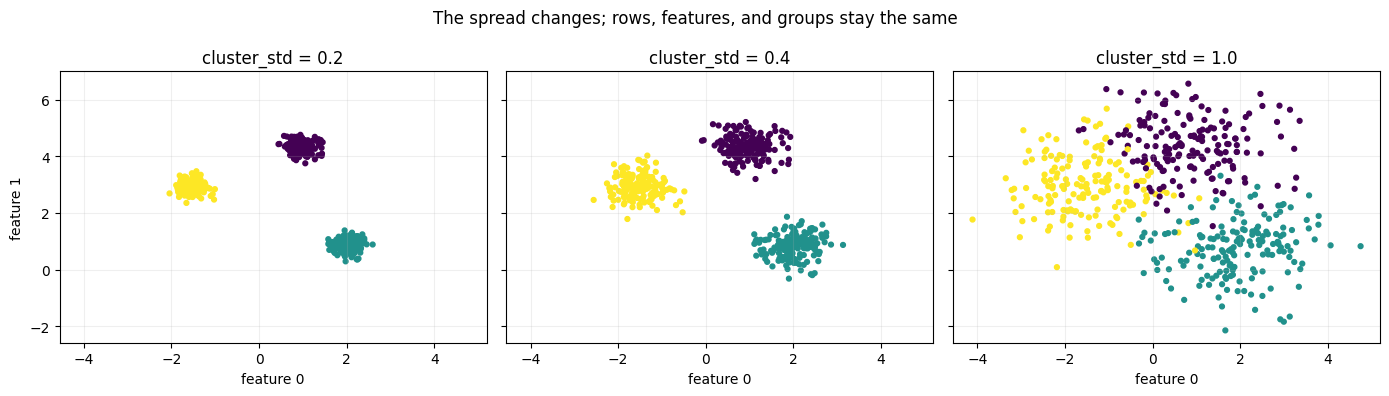

In [60]:
# Compare cluster_std: same 500 rows and 3 groups, different spread.
std_values = [0.2, 0.4, 1.0]
figure, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)

for axis, std_value in zip(axes, std_values):
    demo_x, demo_y = make_blobs(
        n_samples=500,
        centers=3,
        cluster_std=std_value,
        random_state=0
    )
    axis.scatter(demo_x[:, 0], demo_x[:, 1], c=demo_y, s=12)
    axis.set_title(f'cluster_std = {std_value}')
    axis.set_xlabel('feature 0')
    axis.grid(alpha=0.2)

axes[0].set_ylabel('feature 1')
figure.suptitle('The spread changes; rows, features, and groups stay the same')
plt.tight_layout()
plt.show()


### Reading the plot line, once

```
   x[:, 0]   ->  all rows, column 0  ->  the horizontal position
   x[:, 1]   ->  all rows, column 1  ->  the vertical position
```

`:` simply means *everything*. So `x[:, 0]` is "every row, first column only".

You will type this same line many times below. The only part that changes is
`c=...`, which decides the colour of each dot.

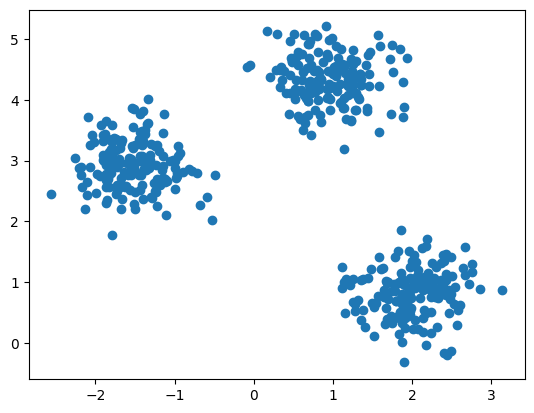

In [3]:
plt.scatter(x[:,0],x[:,1])

## 3. DBSCAN - who is standing in a crowd?

### The story

Look down at a wedding hall from the balcony.

You see three tight groups of people talking. And a few people standing
alone near the walls, part of no group at all.

Nobody told you there were three groups. You saw them, instantly, because of
**how packed together people are**. You spotted the lonely ones the same
way - nobody near them.

That is DBSCAN. The full name is *Density-Based Spatial Clustering of
Applications with Noise*. Forget the name. Remember the balcony.

### The words, before the algorithm

| word | what it means |
| --- | --- |
| **density** | how many points sit close together in a small area |
| **`eps`** | the radius of the circle you draw around a point. Your "arm's length" |
| **`min_samples`** | how many points must be inside that circle before it counts as crowded |
| **core point** | has at least `min_samples` neighbours inside its circle. Standing in the middle of a group |
| **border point** | close to a core point, but not enough neighbours of its own. Standing at the edge of the group |
| **noise point** | neither of the above. Nobody near it. DBSCAN labels it **-1** |

### How it actually runs

```
   pick a point
        |
   draw a circle of radius eps around it
        |
   count the points inside (including itself)
        |
   count >= min_samples ? ---- yes ---> CORE point
        |                               everyone inside joins its cluster
        no
        |
   am I inside somebody else's circle ? -- yes --> BORDER point, I join them
        |
        no
        |
   NOISE.  label = -1
```

Core points that can reach each other chain together into one cluster. That
chaining is why DBSCAN can follow a banana-shaped group, which K-Means
cannot.

### A tiny example you can do by hand

Say `eps = 1` and `min_samples = 3`.

```
   P1(1,1)   P2(1,2)   P3(2,1)              P9(9,9)

   around P1, within distance 1 : P1, P2, P3  -> 3 points -> CORE
   around P9, within distance 1 : only P9     -> 1 point  -> not core
                                               -> not in anyone else's circle
                                               -> NOISE, label -1
```

Three lines of arithmetic, and you already know what the algorithm does.

### Your settings

`eps=0.3, min_samples=10` reads as: *a point is crowded if at least 10
points sit within 0.3 of it.*

`.fit(x)` runs that whole walk for all 500 points and stores the verdicts in
`db.labels_`.

### Before the library: let us measure it by hand

Six points. Few enough that you can check every single number yourself.

```
   A(1,1)  B(2,1)  C(1,2)  D(2,2)      E(3.2, 2)      F(6, 5)
   \_____ a tight square of 4 _____/    a bit away     far away
```

Settings: **eps = 1.5** and **MinPts = 3**.

Read that as: *draw a circle of radius 1.5 around a point. If 3 or more
points sit inside it - counting the point itself - that point is standing in
a crowd.*

Before you run the next cell, make a guess: which of the six will come out
as core, which as boundary, and which as noise?

In [4]:
# How DBSCAN measures. It is plain distance and counting - nothing else.
import math

eps = 1.5
min_pts = 3

names = ['A', 'B', 'C', 'D', 'E', 'F']
points = [(1, 1), (2, 1), (1, 2), (2, 2), (3.2, 2), (6, 5)]

print('STEP 1 - distance from every point to every other point')
print('         ' + '     '.join(names))
for name, p in zip(names, points):
    row = ''
    for q in points:
        row = row + f'{math.dist(p, q):6.2f}'
    print(f'    {name}  {row}')

print()
print(f'STEP 2 - who is inside my circle of radius {eps}, including me?')
neighbours = {}
for name, p in zip(names, points):
    inside = [n for n, q in zip(names, points) if math.dist(p, q) <= eps]
    neighbours[name] = inside
    verdict = 'CORE' if len(inside) >= min_pts else 'not core'
    print(f'    {name} -> {str(inside):22s} count = {len(inside)}   {verdict}')

print()
print('STEP 3 - for the ones that are not core: border or noise?')
kind = {}
for name in names:
    if len(neighbours[name]) >= min_pts:
        kind[name] = 'core'

for name in names:
    if name in kind:
        continue
    near_a_core = [c for c in names if kind.get(c) == 'core' and name in neighbours[c]]
    if near_a_core:
        kind[name] = 'border'
        print(f"    {name} is not core, but it sits inside {near_a_core}'s circle -> BORDER")
    else:
        kind[name] = 'noise'
        print(f"    {name} is not core and sits inside nobody's circle -> NOISE (label -1)")

STEP 1 - distance from every point to every other point
         A     B     C     D     E     F
    A    0.00  1.00  1.00  1.41  2.42  6.40
    B    1.00  0.00  1.41  1.00  1.56  5.66
    C    1.00  1.41  0.00  1.00  2.20  5.83
    D    1.41  1.00  1.00  0.00  1.20  5.00
    E    2.42  1.56  2.20  1.20  0.00  4.10
    F    6.40  5.66  5.83  5.00  4.10  0.00

STEP 2 - who is inside my circle of radius 1.5, including me?
    A -> ['A', 'B', 'C', 'D']   count = 4   CORE
    B -> ['A', 'B', 'C', 'D']   count = 4   CORE
    C -> ['A', 'B', 'C', 'D']   count = 4   CORE
    D -> ['A', 'B', 'C', 'D', 'E'] count = 5   CORE
    E -> ['D', 'E']             count = 2   not core
    F -> ['F']                  count = 1   not core

STEP 3 - for the ones that are not core: border or noise?
    E is not core, but it sits inside ['D']'s circle -> BORDER
    F is not core and sits inside nobody's circle -> NOISE (label -1)


### Read what just happened

| point | inside its own circle | count | verdict |
| --- | --- | --- | --- |
| A | A, B, C, D | 4 | **core** |
| B | A, B, C, D | 4 | **core** |
| C | A, B, C, D | 4 | **core** |
| D | A, B, C, D, **E** | 5 | **core** |
| E | D, E | 2 | **border** |
| F | F | 1 | **noise** |

Look closely at **E**, because E carries the whole lesson.

E has only 2 points inside its own circle, so it fails the MinPts test. E is
not core. But E *does* sit inside D's circle, and D **is** core - so E gets
pulled into D's cluster as a **boundary point**. It joins the group without
ever qualifying to lead it.

Now compare B and E. Their distance is **1.562**, just past 1.5. On the
whiteboard that is a few millimetres, and yet B does not count E at all.

**That is how sharp a threshold is.** There is no "almost inside".

And F? Nothing within 1.5, and F sits inside nobody else's circle either.
No one can reach it. **Noise, label -1.** F is your outlier.

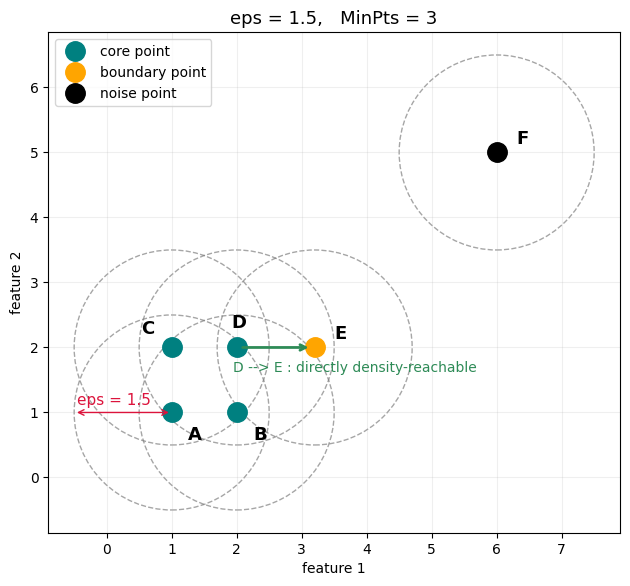

In [5]:
# The whiteboard picture: one circle of radius eps around every point.
colour = {'core': 'teal', 'border': 'orange', 'noise': 'black'}
title = {'core': 'core point', 'border': 'boundary point', 'noise': 'noise point'}
label_spot = {'A': (12, -20), 'B': (12, -20), 'C': (-22, 10),
              'D': (-4, 14), 'E': (14, 6), 'F': (14, 6)}

figure, axis = plt.subplots(figsize=(8, 6.5))
already_named = []

for name, p in zip(names, points):
    this_kind = kind[name]
    axis.add_patch(plt.Circle(p, eps, fill=False, linestyle='--',
                              edgecolor='grey', alpha=0.7))
    legend_text = None
    if this_kind not in already_named:
        legend_text = title[this_kind]
        already_named.append(this_kind)
    axis.plot(p[0], p[1], 'o', markersize=14, color=colour[this_kind],
              label=legend_text)
    axis.annotate(name, p, xytext=label_spot[name], textcoords='offset points',
                  fontsize=13, fontweight='bold')

# what eps actually measures, drawn out from A into empty space
axis.annotate('', xy=(1 - eps, 1), xytext=(1, 1),
              arrowprops=dict(arrowstyle='<->', color='crimson'))
axis.text(-0.45, 1.12, f'eps = {eps}', color='crimson', fontsize=11)

# D is core and E sits inside D's circle, so D reaches E in one step
axis.annotate('', xy=(3.15, 2), xytext=(2.05, 2),
              arrowprops=dict(arrowstyle='->', color='seagreen', lw=2))
axis.text(1.95, 1.62, 'D --> E : directly density-reachable',
          color='seagreen', fontsize=10)

axis.set_title(f'eps = {eps},   MinPts = {min_pts}', fontsize=13)
axis.set_xlabel('feature 1')
axis.set_ylabel('feature 2')
axis.set_aspect('equal')
axis.grid(alpha=0.2)
axis.legend(loc='upper left', fontsize=10)
plt.show()

### The picture, in words

Every dashed circle has radius `eps = 1.5`. **That circle is the only thing
DBSCAN ever looks at.**

```
   teal    = CORE     at least 3 points inside its own circle
   orange  = BORDER   fails that test, but sits inside a core point's circle
   black   = NOISE    fails, and is inside nobody's circle  ->  label -1
```

Two more terms from the whiteboard, and both are simpler than they sound.

**Directly density-reachable** (the green arrow). E is directly
density-reachable from D, because D is core and E is inside D's circle. Say
it plainly: *D can reach E in one step.*

**And it only works one way.** D reaches E. E cannot reach D - because E is
not core, and a non-core point is not allowed to pull anybody in. The arrow
has a direction. This is the detail most people miss.

**Density-connected.** A and E are 2.42 apart, so neither is in the other's
circle. But A reaches D, and D reaches E. Chain the hops and they land in
the same cluster:

```
   A --> D --> E        every hop passes through a CORE point
```

That chaining is why DBSCAN can follow a long curved shape. K-Means, which
only measures distance to a centre, cannot.

In [6]:
# Does sklearn agree with the hand working?
check = DBSCAN(eps=eps, min_samples=min_pts).fit(np.array(points))

print('point order              :', names)
print('sklearn labels_          :', check.labels_)
print('sklearn core points      :', [names[i] for i in check.core_sample_indices_])
print('my hand answer           :', [kind[n] for n in names])

point order              : ['A', 'B', 'C', 'D', 'E', 'F']
sklearn labels_          : [ 0  0  0  0  0 -1]
sklearn core points      : ['A', 'B', 'C', 'D']
my hand answer           : ['core', 'core', 'core', 'core', 'border', 'noise']


### sklearn agrees with you

```
   labels_       = [ 0  0  0  0  0 -1]
   core points   = ['A', 'B', 'C', 'D']
```

Line by line:

- A, B, C, D, E all got label **0**. One cluster - and E is inside it, as a
  boundary point.
- F got **-1**. Noise. Your outlier.
- The core list is exactly the four you counted by hand.

One thing worth noticing: `labels_` does **not** separate core from border.
Both are just `0`. To tell them apart you need `core_sample_indices_` -
which is precisely what the three-panel cell further down uses to colour
them.

### Now scale it up

Your next cell runs these same three steps on 500 points with `eps=0.3` and
`min_samples=10`. Nothing new happens. Just 500 circles instead of 6, and a
required count of 10 instead of 3.

**If you followed A to F, you already understand DBSCAN.**

In [7]:
db = DBSCAN(eps=0.3,min_samples=10).fit(x)

### Two pictures, same dots, different meaning

This is where people get confused, so slow down here.

```
   plt.scatter(..., c=y)           <- colour by the TRUTH
                                      which blob make_blobs created it in

   plt.scatter(..., c=db.labels_)  <- colour by what DBSCAN DISCOVERED
                                      cluster 0, 1, 2 ... and -1 for noise
```

The dots do not move. Only the colours change.

In the second picture, look at the dark dots sitting alone around the edges.
Those are the **-1** points.

Two things just happened, and both are worth noticing. DBSCAN found the same
three groups **without ever seeing `y`**. And it also pointed at the loners,
which `y` never does - `make_blobs` gave every point a blob number, even the
strays.

The cluster numbers will not match `y`. DBSCAN's "cluster 0" might be `y`'s
blob 2. It invented its own numbering, and that is fine.

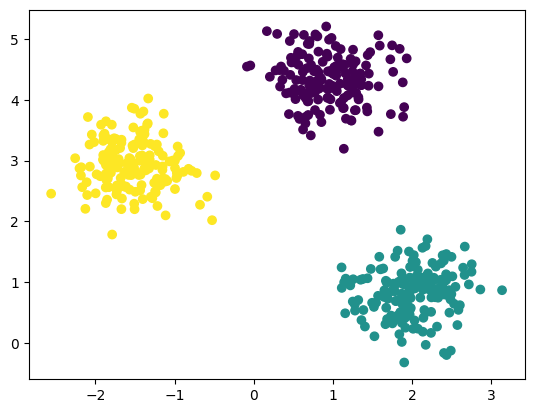

In [8]:
plt.scatter(x[:,0],x[:,1],c=y)

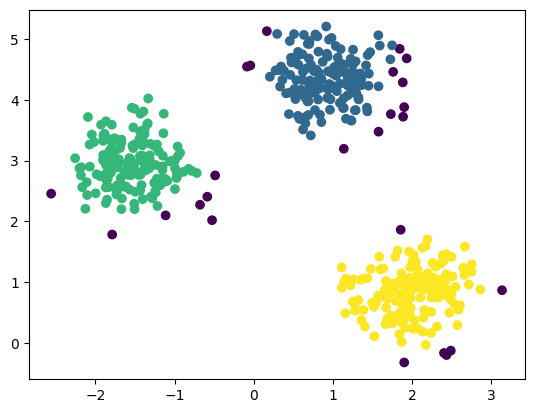

In [9]:
plt.scatter(x[:,0],x[:,1],c=db.labels_)

### Let's change one thing and watch

The data will not move. We change only `eps` - the arm's length - and run
DBSCAN three times.

Answer this before you look at the picture: **if I make the circle smaller,
will there be more noise or less?**

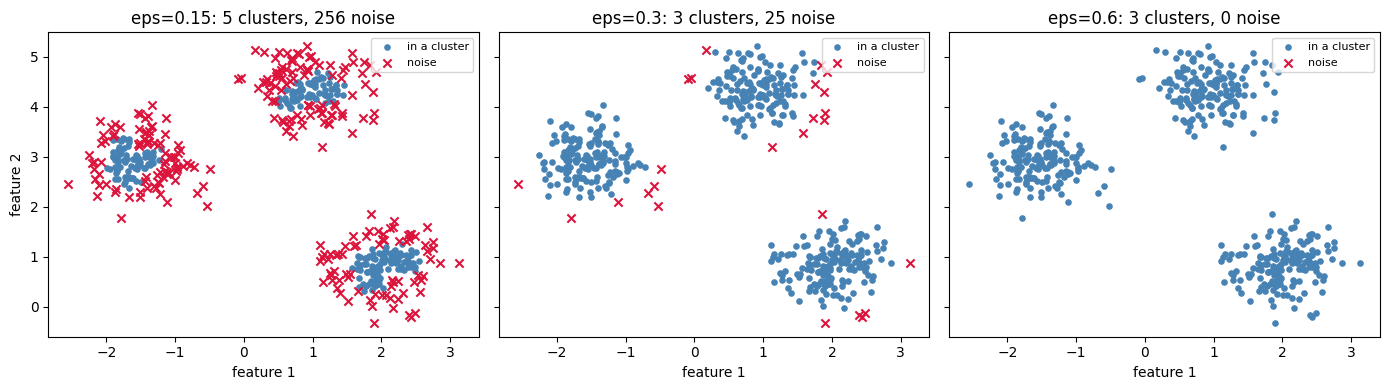

In [10]:
# Teaching experiment: separate names preserve your original x, y, and db.
lesson_db_x = x.copy()
lesson_fig, lesson_axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for lesson_axis, lesson_eps in zip(lesson_axes, [0.15, 0.3, 0.6]):
    lesson_labels = DBSCAN(eps=lesson_eps, min_samples=10).fit_predict(lesson_db_x)
    lesson_noise = lesson_labels == -1  # one True/False value per row
    lesson_groups = len(set(lesson_labels) - {-1})
    lesson_axis.scatter(lesson_db_x[~lesson_noise, 0], lesson_db_x[~lesson_noise, 1],
                        s=14, color='steelblue', label='in a cluster')
    lesson_axis.scatter(lesson_db_x[lesson_noise, 0], lesson_db_x[lesson_noise, 1],
                        s=35, marker='x', color='crimson', label='noise')
    lesson_axis.set_title(f'eps={lesson_eps}: {lesson_groups} clusters, {lesson_noise.sum()} noise')
    lesson_axis.set_xlabel('feature 1')
    lesson_axis.legend(fontsize=8)
lesson_axes[0].set_ylabel('feature 2')
plt.tight_layout()
plt.show()

### What happened

| `eps` | clusters found | noise points |
| --- | --- | --- |
| 0.15 | 5 | **256** |
| 0.30 | 3 | **25** |
| 0.60 | 3 | **0** |

Small circle → hardly anyone has 10 neighbours within reach → half of your
data gets called noise, and real blobs even break into pieces (5 clusters
instead of 3).

Big circle → everyone can reach everyone → nobody is lonely → zero noise.

**Nothing about the data changed. Only your definition of "close" changed.**

### Remember this

DBSCAN does not find outliers by measuring distance from a centre. It finds
them by asking *is anyone near you*. `eps` and `min_samples` are you telling
it what "near" and "enough" mean. Those two numbers decide the answer.

Its weak spot: one single `eps` for the entire dataset. If one group is
tight and another is spread out, no single radius suits both.

## 4. Elliptic Envelope - draw one oval around normal

### The story

A tailor measures a thousand men for shirts: height and chest size.

Plot them and you get one slanted cloud - taller men usually have a wider
chest, so the cloud leans. The tailor draws a single oval around the bulk of
it and says: **inside this oval is a normal body. Outside it, I stitch by
hand.**

That is Elliptic Envelope. One oval. Everything outside it is an outlier.

### The words

| word | what it means |
| --- | --- |
| **centre** | the middle of the normal cloud. Roughly the average row |
| **spread** | how far points usually stray from that centre |
| **covariance** | spread *plus tilt*. It also records that height and chest grow together, which is what makes the oval slant instead of sitting upright |
| **robust** | the important one. While measuring centre and spread, it deliberately ignores the most suspicious rows, so a few freak values cannot drag the oval towards themselves |
| **`contamination`** | *you* tell it what fraction of the data you believe is junk |

Why does "robust" matter so much? Because a plain average is easy to fool.
One order of ₹4,00,000 in a shop where everything costs ₹400 drags the
average up - and then the crazy order looks close to average and escapes.
Robust fitting refuses to let that happen.

### How a point gets judged

Not by plain distance from the centre. By distance **measured in units of
the cloud's own spread, along the cloud's own direction**.

```
   a tall, thin cloud:

        |             a point 2 units to the RIGHT  ->  far outside
        |             a point 2 units UP            ->  perfectly normal
        |
                      same "2", opposite verdicts
```

Then it sorts every row by that distance and chops off the worst
`contamination` share.

### Your setting

`contamination=0.1` means *"I believe about 10% of this data is junk"*. With
2000 rows that is a promise to flag about 200 of them - **whether or not 200
bad rows actually exist**.

This is a knob you turn, not a truth the model discovered. Hold on to that.

In [11]:
x,y = make_blobs(n_samples=2000, centers=2, cluster_std=0.9,random_state=0)

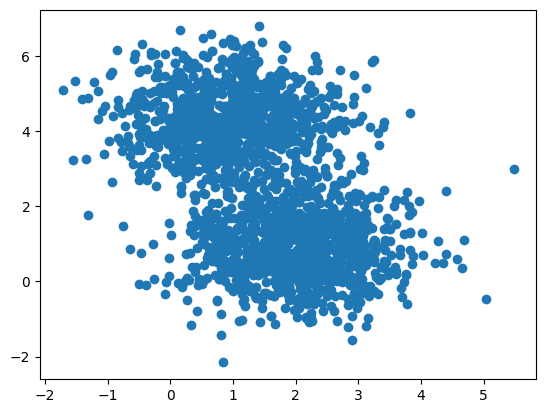

In [12]:
plt.scatter(x[:,0],x[:,1])

### Two steps, and the label code

```
   ee.fit(x)       ->  learn the centre, the spread, and the cutoff distance
   ee.predict(x)   ->  give every row a verdict
```

The verdict is not True/False. It is:

```
   +1  ->  inlier   (normal)
   -1  ->  outlier  (unusual)
```

**Every outlier detector in sklearn uses this same +1 / -1 code.** DBSCAN is
the odd one out, because it is really a clustering algorithm - there, -1
means "noise, belongs to no cluster".

When you plot with `c=prediction`, matplotlib gives the +1 group one colour
and the -1 group another. That is why this picture has exactly two colours,
while the DBSCAN picture had four.

In [13]:
ee = EllipticEnvelope(contamination=0.1)
ee.fit(x)

,"store_precision store_precision: bool, default=TrueSpecify if the estimated precision is stored.",True
,"assume_centered assume_centered: bool, default=FalseIf True, the support of robust location and covariance estimatesis computed, and a covariance estimate is recomputed from it,without centering the data.Useful to work with data whose mean is significantly equal tozero but is not exactly zero.If False, the robust location and covariance are directly computedwith the FastMCD algorithm without additional treatment.",False
,"support_fraction support_fraction: float, default=NoneThe proportion of points to be included in the support of the rawMCD estimate. If None, the minimum value of support_fraction willbe used within the algorithm: `(n_samples + n_features + 1) / 2 * n_samples`.Range is (0, 1).",None
,"contamination contamination: float, default=0.1The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Range is (0, 0.5].",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines the pseudo random number generator for shufflingthe data. Pass an int for reproducible results across multiple functioncalls. See :term:`Glossary <random_state>`.",None
Name,Type,Value
"covariance_ covariance_: ndarray of shape (n_features, n_features)Estimated robust covariance matrix.","ndarray[float64](2, 2)","[[ 0.95,-1.01], [-1.01, 4.02]]"
"dist_ dist_: ndarray of shape (n_samples,)Mahalanobis distances of the training set (on which :meth:`fit` iscalled) observations.","ndarray[float64](2000,)","[1.52,0.1 ,2.5 ,...,0.74,0.9 ,5.49]"
"location_ location_: ndarray of shape (n_features,)Estimated robust location.","ndarray[float64](2,)","[1.48,2.61]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
offset_ offset_: floatOffset used to define the decision function from the raw scores.We have the relation: ``decision_function = score_samples - offset_``.The offset depends on the contamination parameter and is defined insuch a way we obtain the expected number of outliers (samples withdecision function < 0) in training... versionadded:: 0.20,float64,-4.222


In [14]:
prediction = ee.predict(x)

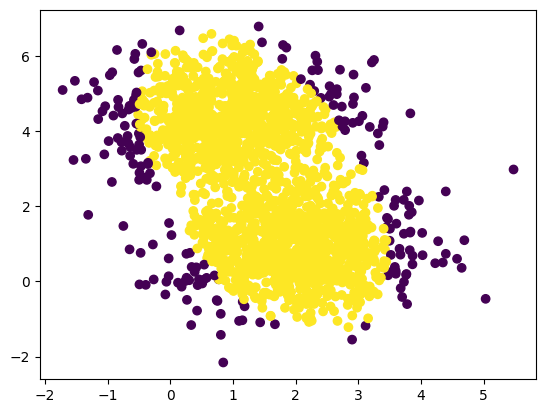

In [15]:
plt.scatter(x[:,0],x[:,1], c= prediction)

### But where is the oval, actually?

The colour picture shows you *which* points were rejected. It does not show
you *the shape that rejected them*.

This experiment draws that boundary line, so you can finally see the oval
the model learned.

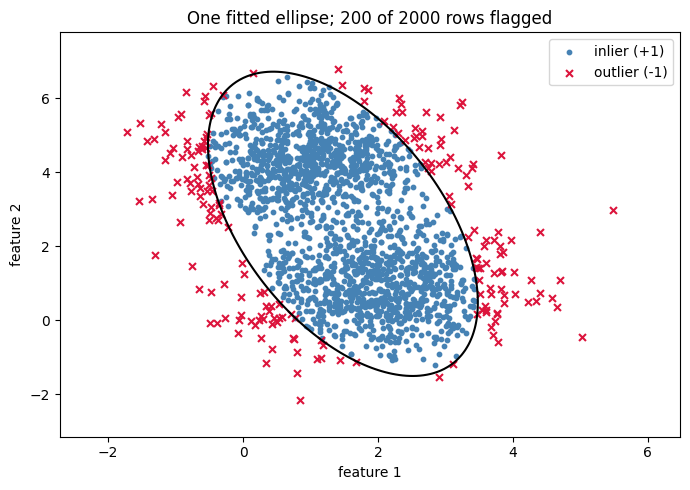

In [16]:
# Use your already-fitted ee and its current two-cloud x.
lesson_ee_flags = ee.predict(x) == -1
lesson_gx, lesson_gy = np.meshgrid(
    np.linspace(x[:, 0].min() - 1, x[:, 0].max() + 1, 180),
    np.linspace(x[:, 1].min() - 1, x[:, 1].max() + 1, 180)
)
lesson_grid = np.column_stack([lesson_gx.ravel(), lesson_gy.ravel()])
lesson_surface = ee.decision_function(lesson_grid).reshape(lesson_gx.shape)
plt.figure(figsize=(7, 5))
plt.scatter(x[~lesson_ee_flags, 0], x[~lesson_ee_flags, 1], s=10,
            color='steelblue', label='inlier (+1)')
plt.scatter(x[lesson_ee_flags, 0], x[lesson_ee_flags, 1], s=25,
            color='crimson', marker='x', label='outlier (-1)')
plt.contour(lesson_gx, lesson_gy, lesson_surface, levels=[0], colors='black')
plt.title(f'One fitted ellipse; {lesson_ee_flags.sum()} of {len(x)} rows flagged')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.tight_layout()
plt.show()

### What happened

**200 rows out of 2000 flagged.** Exactly 10% - exactly what you asked for
with `contamination=0.1`. The model kept its promise.

Now look at the shape: one slanted oval. Your data here was `centers=2` with
`cluster_std=0.9` - two blobs so spread out that they overlap into a single
long diagonal cloud. That is why an oval still fits well.

**And that is also the model's weakness.** Had those two blobs been far
apart, the oval would have stretched to cover both, and the empty gap
*between* them would sit comfortably inside "normal". Elliptic Envelope
believes there is exactly one cloud. When that belief is wrong, it is
confidently wrong.

### Remember this

DBSCAN asks *is anyone near you*.
Elliptic Envelope asks *how far are you from the one centre, in the cloud's
own units*.

Use it when normal data really is one oval blob. Do not use it for several
separate families, or for curved shapes.

## 5. Isolation Forest - how fast can I cut you off?

### The story

Twenty Guess Who cards on the table. All the faces look similar - same age
range, similar hair - except one man wearing a bright red hat.

You start asking random yes/no questions. *"Is the hair dark?" "Glasses?"*

The red hat man is alone after **two** questions.
The other nineteen take **eight or nine** questions each, because they keep
looking like one another and keep splitting into pairs.

**Being easy to separate is the definition of being strange.**

That is the entire algorithm. Notice what it never does: it never measures a
distance, and it never computes a centre.

### The words

| word | what it means |
| --- | --- |
| **isolate** | keep cutting until this one point sits alone in its own box |
| **random cut** | pick a column at random, pick a value at random, split there. No cleverness, no learning |
| **path length** | how many cuts it took before that point was alone. The question count |
| **tree** | one full run of random cuts |
| **forest** | 100 such trees, because one run of random luck proves nothing |

### The picture

```
   500 points
        |
   random cut  ------------->  the lonely point is already alone
        |                      path length = 2
   random cut
        |
   ...  a crowded point keeps getting
        split along with others, for
        8, 9, 10 more cuts
```

```
   short average path over 100 trees  ->  OUTLIER
   long  average path over 100 trees  ->  normal
```

### Why 100 random trees instead of one careful one?

One tree could get lucky and cut a perfectly normal point off early. Average
across 100 independent trees and that luck cancels out.

Same reason a Random Forest grows many trees - you saw exactly this in
notebook 20. The idea travels.

In [17]:
x,y = make_blobs(n_samples=500, centers=3, cluster_std=0.4,random_state=0)

### Your four lines

```
   iso = IsolationForest()    ->  build the recipe. Nothing has happened yet
   iso.fit(x)                 ->  grow 100 trees of random cuts on your data
   pred = iso.predict(x)      ->  +1 / -1 for every row
   plt.scatter(..., c=pred)   ->  colour the dots by that verdict
```

You left the settings at their defaults, which means:

- `n_estimators=100` - one hundred trees.
- `contamination='auto'` - *"you work out the cutoff, do not ask me."*

Now compare this picture with the DBSCAN picture higher up. **Same 500
points.**

- DBSCAN flagged **25** lonely points, right at the far edges.
- Isolation Forest flagged an entire **outer shell** around each blob.

Neither is wrong. They were asked different questions. DBSCAN was told
"10 neighbours within 0.3 is enough". Isolation Forest was told nothing, so
`'auto'` applied its own generous cutoff and called every fringe point
unusual.

**A detector is only as strict as the threshold you hand it.**

In [18]:
iso = IsolationForest()

In [19]:
iso.fit(x)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ax_features=1)


In [20]:
pred = iso.predict(x)

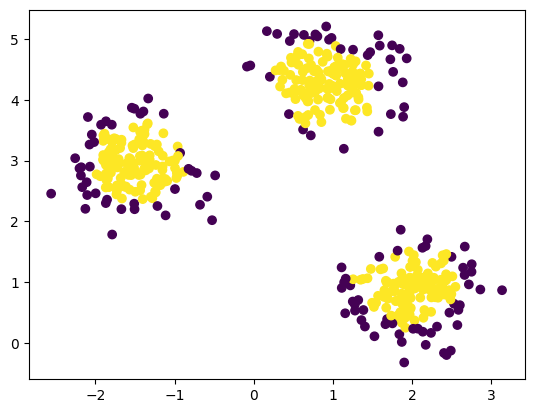

In [21]:
plt.scatter(x[:,0],x[:,1],c=pred)

### Inside the box: from path length to +1 / -1

Three names, in the order they get computed.

| name | what it is |
| --- | --- |
| `score_samples(x)` | the raw score for each row, built from its average path length. **More negative = isolated faster = more suspicious** |
| `offset_` | the cutoff line. With `contamination='auto'` it is fixed at **-0.5** |
| `decision_function(x)` | just `score_samples - offset_`. It slides the cutoff to **zero** |

After that, the rule is a single comparison:

```
   decision_function(row)  <  0   ->  -1  (outlier)
   decision_function(row) >=  0   ->  +1  (inlier)
```

Now read the three printed rows with that in mind:

```
   row 442 :  raw -0.645  ->  -0.645 - (-0.5) = -0.145  ->  negative  ->  -1
   row 415 :  raw -0.470  ->  -0.470 - (-0.5) = +0.030  ->  positive  ->  +1
   row 181 :  raw -0.425  ->  -0.425 - (-0.5) = +0.075  ->  positive  ->  +1
```

Do that subtraction once with your own pen. After that
`decision_function` will never look mysterious again.

**The big idea:** the model produces a *continuous score* - a smooth line
running from very suspicious to very normal. The +1 / -1 label is only that
score with a cutoff applied. Change `contamination` and you move the cutoff;
the scores themselves do not move at all.

That should feel familiar. It is the same threshold idea from the ROC
notebook, wearing a different costume.

score offset: -0.5
row | score_samples | decision score | predicted label
442 |        -0.645 |         -0.145 | -1
415 |        -0.470 |          0.030 | +1
181 |        -0.425 |          0.075 | +1


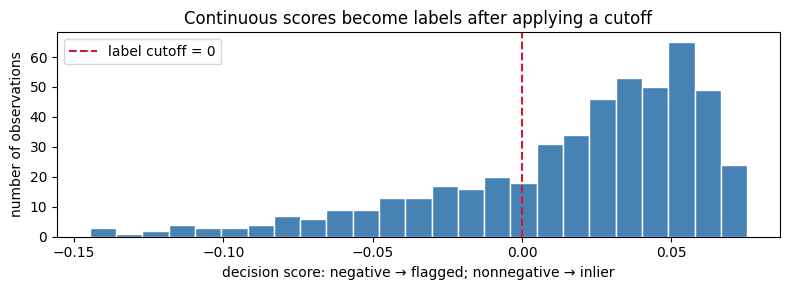

In [22]:
# Reproducible score experiment on the same three-cloud data.
lesson_iso = IsolationForest(random_state=0).fit(x)
lesson_raw = lesson_iso.score_samples(x)
lesson_decision = lesson_iso.decision_function(x)
lesson_flags = lesson_iso.predict(x) == -1
print('score offset:', lesson_iso.offset_)
print('row | score_samples | decision score | predicted label')
for lesson_i in np.argsort(lesson_raw)[[0, len(x) // 2, -1]]:
    print(f'{lesson_i:3d} | {lesson_raw[lesson_i]:13.3f} | '
          f'{lesson_decision[lesson_i]:14.3f} | {(-1 if lesson_flags[lesson_i] else 1):+d}')
plt.figure(figsize=(8, 3))
plt.hist(lesson_decision, bins=25, color='steelblue', edgecolor='white')
plt.axvline(0, color='crimson', linestyle='--', label='label cutoff = 0')
plt.xlabel('decision score: negative → flagged; nonnegative → inlier')
plt.ylabel('number of observations')
plt.title('Continuous scores become labels after applying a cutoff')
plt.legend()
plt.tight_layout()
plt.show()

### Reading the histogram

Each bar counts how many rows landed at that score. The dashed red line is
zero - the cutoff.

Everything to the left got `-1`. Everything to the right got `+1`.

Notice there is **no gap at the line**. The scores flow smoothly straight
across it. A row just left of the line and a row just right of it are
practically identical points. They ended up in different classes only
because a line had to be drawn somewhere.

## 6. Why do all these scatter plots look the same?

You spotted this yourself, and it is a good catch. Every plot is the same
500 dots in the same positions. Only `c=` changes.

```
   c=y             ->  the truth from make_blobs        3 colours
   c=db.labels_    ->  clusters DBSCAN discovered       3 colours + noise (-1)
   c=pred          ->  Isolation Forest verdict         2 colours (+1 / -1)
```

Underneath, two different jobs are being mixed up:

| | clustering | outlier detection |
| --- | --- | --- |
| the question | "which group does this belong to?" | "is this one strange?" |
| the output | a group number: 0, 1, 2, ... | a verdict: +1 or -1 |
| how many colours | as many as there are groups | always two |
| in this notebook | DBSCAN | Elliptic Envelope, Isolation Forest, LOF |

DBSCAN is quietly doing *both*. It produces groups **and** a leftover pile
labelled -1. That leftover pile is the only reason it appears in a notebook
about outliers.

So the honest answer to *"is clustering happening here?"* - in the DBSCAN
plot, yes. In the Isolation Forest plot, no.

### And what is clustering, really?

Two words worth separating properly, because everything here rests on them.

**Supervised learning** - you have the answer column. The iris species in
notebook 20, for example. You show the model the answers, and it learns to
reproduce them.

**Unsupervised learning** - there is no answer column. Nobody knows the
right groups. The algorithm has to notice the structure on its own.

```
   supervised    :  here are 500 flowers AND their species
                    -> learn to predict the species

   unsupervised  :  here are 500 points.
                    -> anything interesting?
```

Everything in this notebook is unsupervised. Real anomaly work usually is,
for one simple reason: **nobody labelled the fraud for you.** If you already
had a clean "fraud yes/no" column, you would train a classifier and go home.

Where clustering earns its keep in real systems: grouping customers who
behave alike, grouping sensors that misbehave together, grouping support
tickets about the same underlying problem.

### Back to DBSCAN: opening the box

The next cell re-runs DBSCAN on the three-blob data and lays the stages side
by side. It also rebuilds `x`, `y` and `db`, so from here on those names
point at the three-blob data again.

```
   panel 1 :  raw dots. No groups yet. What the algorithm starts with.
   panel 2 :  the labels DBSCAN produced. Black = -1 = noise.
   panel 3 :  the three kinds of point, in colour.
```

`db.core_sample_indices_` is the list of rows that qualified as core points.
Anything that is neither core nor noise is a border point.

The counts it prints:

```
   core points   : 415   <- had 10+ neighbours within 0.3. The heart of each blob
   border points :  60   <- touching a core point, but thin on their own. The rim
   noise points  :  25   <- reached by nobody. THESE are the outliers
   clusters      :   3
```

415 + 60 + 25 = 500. Every single point is exactly one of the three kinds.

### Remember this

DBSCAN's outliers are not a percentage you chose. They are simply whoever is
left over once the crowds have claimed everyone they can reach.

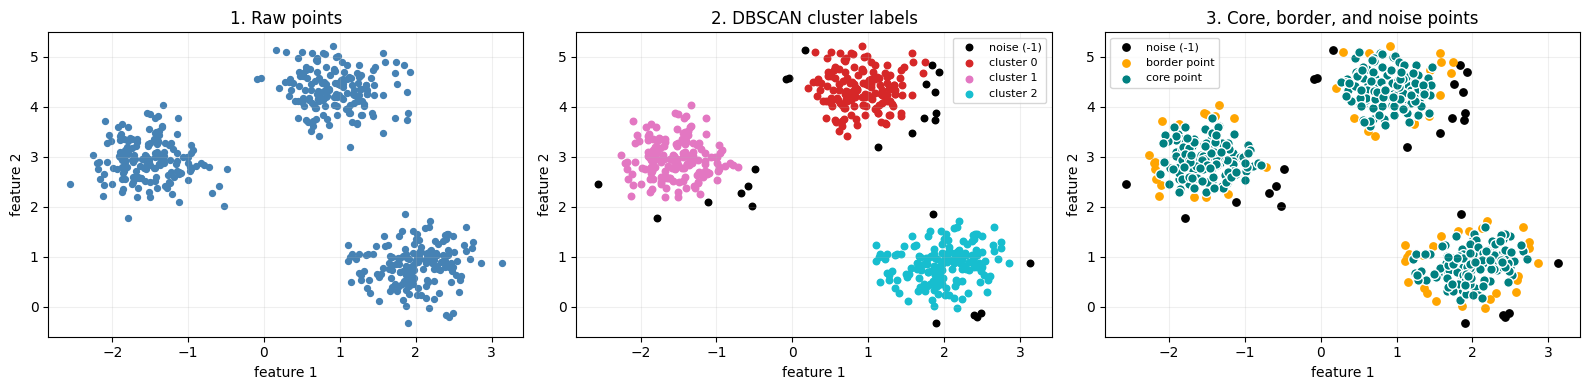

Clusters found: 3
Core points: 415
Border points: 60
Noise points: 25


In [23]:
# Visualize DBSCAN's discovered clusters and point types
from matplotlib.lines import Line2D

# Use the three-cluster data for a clear DBSCAN example.
x, y = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=0.4,
    random_state=0
)
db = DBSCAN(eps=0.3, min_samples=10).fit(x)
labels = db.labels_
core_mask = np.zeros(labels.shape, dtype=bool)
core_mask[db.core_sample_indices_] = True

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Raw points: no groups have been assigned yet.
axes[0].scatter(x[:, 0], x[:, 1], s=18, color="steelblue")
axes[0].set_title("1. Raw points")

# 2. DBSCAN's discovered cluster IDs.
cluster_ids = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(cluster_ids), 1)))
for color, cluster_id in zip(colors, cluster_ids):
    point_mask = labels == cluster_id
    point_color = "black" if cluster_id == -1 else color
    axes[1].scatter(
        x[point_mask, 0],
        x[point_mask, 1],
        s=22,
        color=point_color,
        label="noise (-1)" if cluster_id == -1 else f"cluster {cluster_id}"
    )
axes[1].set_title("2. DBSCAN cluster labels")
axes[1].legend(fontsize=8)

# 3. Core points build the dense regions; border points join from the edge.
noise_mask = labels == -1
border_mask = ~core_mask & ~noise_mask
axes[2].scatter(
    x[noise_mask, 0], x[noise_mask, 1],
    s=28, color="black", label="noise (-1)"
)
axes[2].scatter(
    x[border_mask, 0], x[border_mask, 1],
    s=28, color="orange", label="border point"
)
axes[2].scatter(
    x[core_mask, 0], x[core_mask, 1],
    s=48, color="teal", edgecolors="white", label="core point"
)
axes[2].set_title("3. Core, border, and noise points")
axes[2].legend(fontsize=8)

for axis in axes:
    axis.set_xlabel("feature 1")
    axis.set_ylabel("feature 2")
    axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Clusters found: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Core points: {core_mask.sum()}")
print(f"Border points: {border_mask.sum()}")
print(f"Noise points: {noise_mask.sum()}")


## 7. Local Outlier Factor - strange compared to your own neighbours

### The story

Two people, each standing 5 metres away from anyone else.

The first is in the middle of a packed festival, where everybody else is
half a metre apart. Five metres there is **very** odd. Something is wrong.

The second is in a quiet park where people naturally spread out ten metres
apart. Five metres there is perfectly normal.

**Same 5 metres. Two opposite verdicts.**

The other three methods cannot express this. They judge a point against
*the whole dataset*. LOF judges a point against **its own immediate
neighbours only**. That is the work the word **Local** is doing in the name.

### The words

| word | what it means |
| --- | --- |
| **neighbours** | your `k` nearest points. Nobody else is consulted |
| **local density** | how tightly packed your own little neighbourhood is. Neighbours close by = high density |
| **LOF score** | your neighbours' density ÷ your density |

### Reading the score

```
   LOF around 1  ->  I am as crowded as my neighbours     ->  normal
   LOF above 1   ->  my neighbours are packed, I am not   ->  OUTLIER
   LOF below 1   ->  I sit in an even denser spot         ->  very normal
```

It is a **ratio**, not a distance. That single design choice is the whole
trick.

In [24]:
from sklearn.neighbors import LocalOutlierFactor

### What `LocalOutlierFactor(n_neighbors=3)` does

`n_neighbors=3` means: **my neighbourhood is my 3 nearest points.**

For every row:

```
   1. find my 3 nearest neighbours
   2. measure how tightly packed I am                ->  my density
   3. measure how tightly packed each of them is
   4. LOF = their average density / my density
   5. LOF clearly above 1  ->  label -1
```

Two syntax details worth knowing, because both will trip you up otherwise.

**Use `fit_predict(x)`, not `fit` then `predict`.** By default LOF has no
`.predict()` at all. It is built to examine one fixed dataset, not to judge
new rows later. Calling `fit` on its own trains it but hands you nothing
back. `fit_predict` trains *and* returns the +1 / -1 array - which is why
your cell calls it right after `fit`.

**`negative_outlier_factor_` stores the scores negated** - it holds -1.2
where the real LOF is 1.2. sklearn's house rule is *higher means more
normal*, and that rule must hold for every detector it ships. So
`-clf.negative_outlier_factor_` gives you back the plain LOF value that you
can compare against 1.

In [25]:
clf = LocalOutlierFactor(n_neighbors=3)
clf.fit(x)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",3
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",False
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strThe effective metric used for the distance computation.,str,'eu...an'


In [26]:
pred = clf.fit_predict(x)

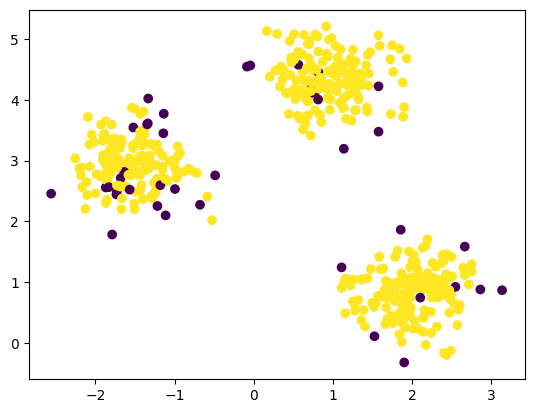

In [27]:
plt.scatter(x[:,0],x[:,1],c=pred)

### Look at what LOF flagged

Put this picture next to the Isolation Forest one.

Isolation Forest flagged a clean outer ring around each blob. LOF flagged a
scattered handful instead - and some of them are not at the outer edge at
all.

That is correct behaviour, not a bug. LOF is not asking *"are you far from
the middle?"*. It is asking *"is your little pocket thinner than your
neighbours' pockets?"*

A point sitting in a small hole *inside* a blob can fail that test. A point
right on the outer edge, with company nearby, can pass it.

### Remember this

LOF compares densities. Reach for it when your data has regions of different
density - a dense city and a sparse village in the same table - because the
other three methods would simply flag the whole village.

In [28]:
x = np.array([[1,5],[1,6],[1,7],[2,5],[2,6],[6,5],[9,1]])

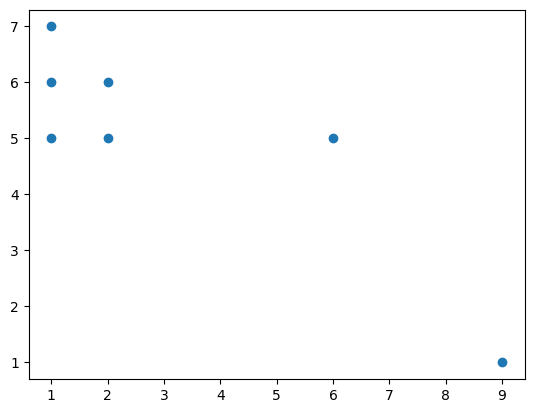

In [29]:
plt.scatter(x[:,0],x[:,1])
plt.show()

## 8. A tiny 7-point example - and a trap

Seven points, small enough to hold in your head:

```
   A(1,5)  B(1,6)  C(1,7)  D(2,5)  E(2,6)      F(6,5)       G(9,1)
   \_________ five points, packed together ____/   far away   very far away
```

Before running anything, answer out loud: which ones do you expect to be
flagged?

### Now read the next cell very carefully

```python
X = x[:,0]           # takes ONLY column 0  ->  1, 1, 1, 2, 2, 6, 9
y = x[:,1]           # column 1 kept aside, only for drawing
X = X.reshape(-1,1)  # make it a column: 7 rows, 1 column
clf.fit(X)           # so LOF sees ONE feature
```

**This is the trap, and it catches almost everybody once.**

`reshape(-1,1)` did **not** add any information. It only changed the shape,
from a flat list of 7 numbers into 7 rows of 1 number - because sklearn
always wants `(rows, columns)`. The `-1` means *"you work that number out
yourself"*.

So the model is now solving a **one-feature** problem. But your scatter plot
still draws both columns. The picture looks two-dimensional while the model
was blind in one eye.

**Whenever a result surprises you, check the shape of what you actually fed
the model.** That habit will save you hours.

In [30]:
X = x[:,0]
y = x[:,1]

X = X.reshape(-1,1)
clf = LocalOutlierFactor(n_neighbors=3)
clf.fit(X)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",3
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",False
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strThe effective metric used for the distance computation.,str,'eu...an'


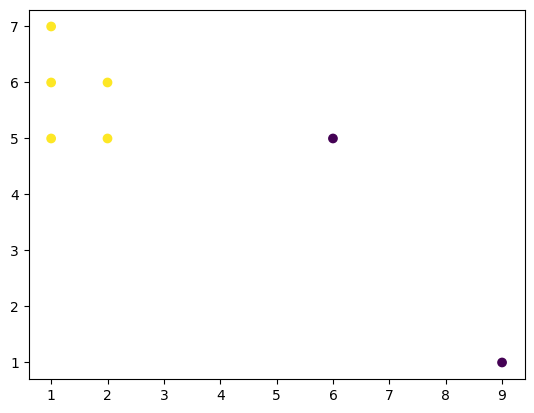

In [31]:
pred = clf.fit_predict(X)
plt.scatter(X, y,c=pred)

### The same seven dots, twice

Left panel: LOF sees column 1 only, exactly like your cell above.
Right panel: LOF sees both columns.

Both panels *draw* both columns, so the comparison is fair - only the input
to the model changed.


LOF sees feature 1 only; input shape = (7, 1)
row | positive LOF | label
A   |        1.000 | +1
B   |        1.000 | +1
C   |        1.000 | +1
D   |        1.000 | +1
E   |        1.000 | +1
F   |        3.611 | -1
G   |        4.400 | -1

LOF sees both features; input shape = (7, 2)
row | positive LOF | label
A   |        0.898 | +1
B   |        1.205 | +1
C   |        1.073 | +1
D   |        1.032 | +1
E   |        0.898 | +1
F   |        3.316 | -1
G   |        4.139 | -1


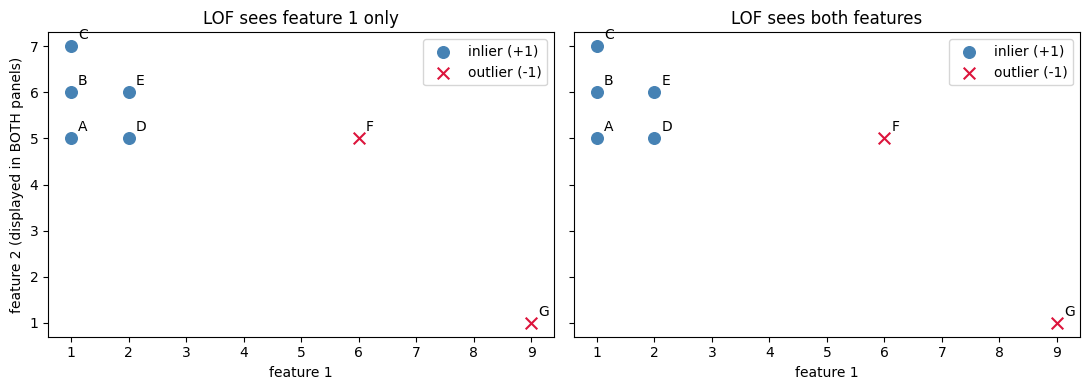

In [32]:
# Compare without overwriting your original X, y, clf, or pred.
lesson_small = x.copy()
lesson_inputs = [lesson_small[:, [0]], lesson_small]
lesson_titles = ['LOF sees feature 1 only', 'LOF sees both features']
lesson_fig, lesson_axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
lesson_names = list('ABCDEFG')
for lesson_axis, lesson_input, lesson_title in zip(lesson_axes, lesson_inputs, lesson_titles):
    lesson_lof = LocalOutlierFactor(n_neighbors=3)
    lesson_prediction = lesson_lof.fit_predict(lesson_input)
    lesson_positive_lof = -lesson_lof.negative_outlier_factor_
    print('\n' + lesson_title + f'; input shape = {lesson_input.shape}')
    print('row | positive LOF | label')
    for lesson_name, lesson_score, lesson_label in zip(lesson_names, lesson_positive_lof, lesson_prediction):
        print(f'{lesson_name:3s} | {lesson_score:12.3f} | {lesson_label:+d}')
    for lesson_label, lesson_color, lesson_marker, lesson_text in [
        (1, 'steelblue', 'o', 'inlier (+1)'), (-1, 'crimson', 'x', 'outlier (-1)')
    ]:
        lesson_mask = lesson_prediction == lesson_label
        lesson_axis.scatter(lesson_small[lesson_mask, 0], lesson_small[lesson_mask, 1],
                            color=lesson_color, marker=lesson_marker, s=70, label=lesson_text)
    for lesson_name, lesson_point in zip(lesson_names, lesson_small):
        lesson_axis.annotate(lesson_name, lesson_point, xytext=(5, 5), textcoords='offset points')
    lesson_axis.set_title(lesson_title)
    lesson_axis.set_xlabel('feature 1')
    lesson_axis.legend()
lesson_axes[0].set_ylabel('feature 2 (displayed in BOTH panels)')
plt.tight_layout()
plt.show()

### What changed

| point | LOF, 1 feature | LOF, 2 features |
| --- | --- | --- |
| A | 1.000 | 0.898 |
| B | 1.000 | 1.205 |
| C | 1.000 | 1.073 |
| D | 1.000 | 1.032 |
| E | 1.000 | 0.898 |
| **F** | **3.611** | **3.316** |
| **G** | **4.400** | **4.139** |

With one feature, A to E score **exactly 1.000**. Look at why: dropping
column 1 collapsed A, B and C onto the identical value (all three have
feature 1 = 1). Their neighbourhood became perfectly tight - suspiciously
perfect.

With both features they get honest, slightly different scores. F and G are
flagged either way here, but now for a real reason rather than by accident.

**Syntax note:** `x[:, [0]]`, with the column number *inside a list*, keeps
the result two-dimensional - shape `(7, 1)`. Plain `x[:, 0]` gives shape
`(7,)` and sklearn refuses it. It is the tidier alternative to
`reshape(-1,1)`.

In [33]:
print('k | positive LOF for F | positive LOF for G | rows flagged')
for lesson_k in [2, 3, 6]:
    lesson_k_model = LocalOutlierFactor(n_neighbors=lesson_k)
    lesson_k_labels = lesson_k_model.fit_predict(lesson_small)
    lesson_k_scores = -lesson_k_model.negative_outlier_factor_
    lesson_flag_names = [name for name, label in zip(lesson_names, lesson_k_labels) if label == -1]
    print(f'{lesson_k} | {lesson_k_scores[5]:18.3f} | {lesson_k_scores[6]:18.3f} | {lesson_flag_names}')

k | positive LOF for F | positive LOF for G | rows flagged
2 |              4.062 |              4.070 | ['F', 'G']
3 |              3.316 |              4.139 | ['F', 'G']
6 |              1.074 |              0.970 | []


### The last experiment: what does `k` really control?

| `k` | LOF of F | LOF of G | flagged |
| --- | --- | --- | --- |
| 2 | 4.062 | 4.070 | F, G |
| 3 | 3.316 | 4.139 | F, G |
| 6 | 1.074 | 0.970 | **nobody** |

At `k=6`, with only 7 points in total, "my neighbourhood" has become almost
the entire dataset. Local stopped being local.

Look at G at `k=6`: its score drops *below* 1. The algorithm now considers
the loneliest point in the data perfectly normal.

**`n_neighbors` is not a small tuning detail. It is your definition of the
word "local", and it can flip the answer completely.**

Rough guidance: too small, and random noise starts looking like structure.
Too large, and you throw away the very locality that made LOF worth using.
`k=20` is the usual starting point on real data. Seven points is far too few
for LOF to mean anything - which is exactly why it makes a good teaching
example.

---

## Putting the four side by side

| method | the question it asks | you must choose | what it flags |
| --- | --- | --- | --- |
| **DBSCAN** | is anyone near me? | `eps`, `min_samples` | whoever is left over |
| **Elliptic Envelope** | how far am I from the one centre? | `contamination` | exactly that percentage |
| **Isolation Forest** | how few cuts to isolate me? | `contamination` | that percentage, or `'auto'` |
| **LOF** | is my pocket thinner than my neighbours'? | `n_neighbors` | those with a high ratio |

### When to use which

| your situation | use |
| --- | --- |
| one roughly oval cloud of normal data | Elliptic Envelope |
| many columns, plenty of rows, no idea of the shape | Isolation Forest - the usual first choice |
| odd-shaped groups, and you want the groups too | DBSCAN |
| dense and sparse regions in the same dataset | LOF |

### When NOT to use them

- Elliptic Envelope on several separate clouds - the oval swallows the empty
  gap between them and calls it normal.
- DBSCAN when groups have very different densities - one `eps` cannot serve
  both.
- LOF with `k` close to the size of your data - locality disappears, as you
  just saw.
- Any of them on unscaled columns. Rupees in lakhs sitting beside age in
  years means the rupee column decides everything. Scale first.

---

## Remember this

**These algorithms do not find wrong rows. They find rows that do not fit
the pattern they were told to look for.**

Four different definitions of "the pattern" gave four different answers on
the very same 500 points. That definition is your choice - and that choice,
not the algorithm, is where the real engineering work sits.

## 60-second revision

1. Outlier = unusual, not wrong. A human still decides.
2. Unsupervised - no answer key. That is why these methods exist at all.
3. sklearn's verdict code: **+1 normal, -1 unusual**.
4. DBSCAN: crowds. `eps` = arm's length, `min_samples` = enough. Noise = -1.
5. Elliptic Envelope: one robust oval, and *you* set `contamination`.
6. Isolation Forest: random cuts. Isolated fast = strange. Score first,
   label after a cutoff.
7. LOF: my density vs my neighbours' density. Ratio near 1 = normal.
8. `reshape(-1,1)` changes shape, never information.

## Test yourself

- Why did `eps=0.6` produce zero noise points?
- With `contamination=0.1` on 2000 rows, how many rows get flagged - before
  you have even looked at the data?
- A point sits far from everything, but its few neighbours are also spread
  far apart. High LOF or low?
- Which of the four never measures a distance at all?